# 🌳 Modulo 23: Árboles de Decisión (Decision Trees)

¡Bienvenido/a al mundo del Machine Learning explicable!

En modelos anteriores (como SVM o Regresión), la matemática dictaba fronteras complejas. Sin embargo, en el mundo real (como en la medicina o los negocios), a veces necesitamos explicar exactamente *por qué* el algoritmo tomó una decisión. Los **Árboles de Decisión** resuelven esto creando un mapa de reglas escalonadas, dividiendo los datos mediante preguntas lógicas hasta llegar a un veredicto.

## 🚀 Contenido del Cuaderno

1. **Fundamentos:** Algoritmo de Hunt, CART y Nodos Puros.
2. **Matemática de la Decisión:** Criterio de Gini vs. Entropía.
3. **Implementación Práctica:** Predicción de medicamentos recetados (`drugs.csv`).
4. **Visualización Gráfica:** Dibujando el mapa de decisiones.
5. **Nivel Pro:** Poda del árbol (Pruning) y Optimización de Hiperparámetros.
6. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas paso a paso. Asegúrate de tener el archivo `drugs.csv` en tu directorio de trabajo.

## 1. Fundamentos: ¿Cómo crece un árbol?



Un árbol de decisión se construye de arriba hacia abajo (top-down) siguiendo el **Algoritmo de Hunt**:
1. **Nodo Raíz (Root):** Comienza con todos los datos en un solo bloque. El algoritmo busca la variable que divida mejor a los pacientes en grupos distintos.
2. **Nodos de Decisión:** Reglas intermedias (Ej. "¿El paciente tiene Presión Alta?").
3. **Hojas (Leaf Nodes / Nodos Puros):** El punto final. Un "Nodo Puro" es aquel donde el 100% de los registros pertenecen a la misma categoría (Ej. Todos en este grupo toman la Droga Y).

En Python utilizamos la implementación **CART (Classification and Regression Trees)**, la cual asegura que cada pregunta tenga solo dos respuestas posibles (divisiones binarias).

## 2. La Matemática: ¿Gini o Entropía?

¿Cómo sabe el algoritmo qué pregunta hacer primero? Calcula la "impureza" o el caos de los datos.



* **Criterio de Gini:** Mide la probabilidad de clasificar incorrectamente un elemento elegido al azar. Busca minimizar esta probabilidad.
  $$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
* **Entropía:** Un concepto traído de la teoría de la información. Mide el nivel de desorden. Si un grupo tiene 50% pacientes de Droga A y 50% de Droga B, la entropía es máxima (1.0). Si todos son de Droga A, la entropía es 0 (Nodo Puro).
  $$Entropia = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

Ambos criterios suelen dar resultados similares, pero probar ambos es una buena práctica de optimización.

---
## 📝 Proyecto Práctico: Clasificación Farmacológica

**Objetivo:** Desarrollar un modelo que aprenda de datos históricos (`drugs.csv`) para recomendar qué medicamento (`Drug`) recetar a un paciente nuevo basándonos en su Edad, Sexo, Presión Sanguínea (BP), Colesterol y niveles de Sodio/Potasio (`Na_to_K`).

**Paso 1: Preprocesamiento y Codificación**
Los árboles matemáticos necesitan números. Transformaremos nuestras variables cualitativas (texto) en formato numérico.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar el dataset de medicamentos
df_drugs = pd.read_csv('drugs.csv')

print("=== Exploración Inicial de Datos ===")
display(df_drugs.head())

# 2. Codificación de Variables Cualitativas
# Transformamos el dataset para el modelado matemático:
#   - df.drop: Retiramos 'Drug' ya que será nuestra variable a predecir (y).
#   - get_dummies: Convertimos categorías de texto a columnas binarias (1 y 0).
#   - drop_first: Eliminamos una categoría base por variable para asegurar 
#                 la independencia lineal y evitar multicolinealidad.
X = pd.get_dummies(df_drugs.drop('Drug', axis=1), drop_first=True)

# Para la variable objetivo (y), la dejamos como  está, ya que Scikit-Learn
# maneja etiquetas de texto internamente para la clasificación
y = df_drugs['Drug']

# 3. División en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Datos preparados. Dimensiones de entrenamiento: {X_train.shape}")
print(f"Clases a predecir: {y.unique()}")

=== Exploración Inicial de Datos ===


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY



✅ Datos preparados. Dimensiones de entrenamiento: (160, 6)
Clases a predecir: ['drugY' 'drugC' 'drugX' 'drugA' 'drugB']


### Paso 2: Implementación y Comparación de Criterios
Vamos a entrenar dos Árboles de Decisión simultáneamente: uno utilizando la métrica de **Gini** y otro usando **Entropía**, para evaluar cuál se adapta mejor a nuestra base de datos.

=== DESEMPEÑO DEL MODELO (GINI) ===
Precisión Global (Accuracy: 0.9750
=== DESEMPEÑO DEL MODELO (ENTROPÍA) ===
Precisión Global (Accuracy: 0.9750

=== REPORTE DE CLASIFICACIÓN DETALLADO (ENTROPÍA) ===
              precision    recall  f1-score   support

       drugA       0.83      1.00      0.91         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



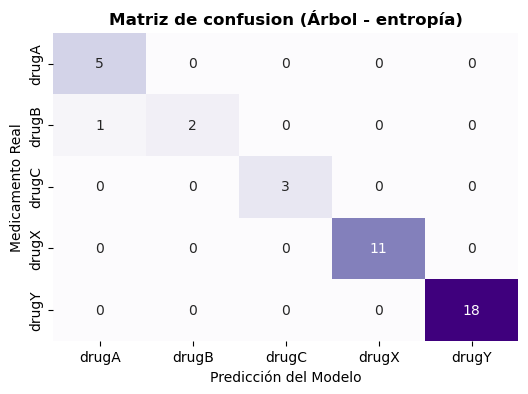

In [6]:
# --- Entrenando Modelos --- 
# Modelo 1: Criterio Gini
arbol_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
arbol_gini.fit(X_train, y_train)
pred_gini = arbol_gini.predict(X_test)

# Modelo 2: Criterio Entropía
arbol_entropia = DecisionTreeClassifier(criterion='entropy', random_state=42)
arbol_entropia.fit(X_train, y_train)
pred_entropia = arbol_entropia.predict(X_test)

# --- Evaluación ---
print("=== DESEMPEÑO DEL MODELO (GINI) ===")
print(f"Precisión Global (Accuracy: {accuracy_score(y_test, pred_gini):.4f}")

print("=== DESEMPEÑO DEL MODELO (ENTROPÍA) ===")
print(f"Precisión Global (Accuracy: {accuracy_score(y_test, pred_entropia):.4f}")

# Detalle del Reporte de Clasificación (Usando Entropía como ejemplo)
print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO (ENTROPÍA) ===")
print(classification_report(y_test, pred_entropia))

# --- Matriz de Confusión Visual ---
cm = confusion_matrix(y_test, pred_entropia)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
           xticklabels=arbol_entropia.classes_,
           yticklabels=arbol_entropia.classes_)
plt.title('Matriz de confusion (Árbol - entropía)', fontweight='bold')
plt.ylabel('Medicamento Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### Paso 3: Visualización Gráfica del Árbol de Decisión
Una de las mayores ventajas de este algoritmo es que podemos "imprimir" su cerebro. 
*(Nota Técnica: Históricamente se usa `Graphviz` y `pydotplus` para exportar en PDF, pero las versiones modernas de Scikit-Learn incluyen `plot_tree`, que nos permite dibujarlo de forma nativa sin depender de instalaciones externas de software).*

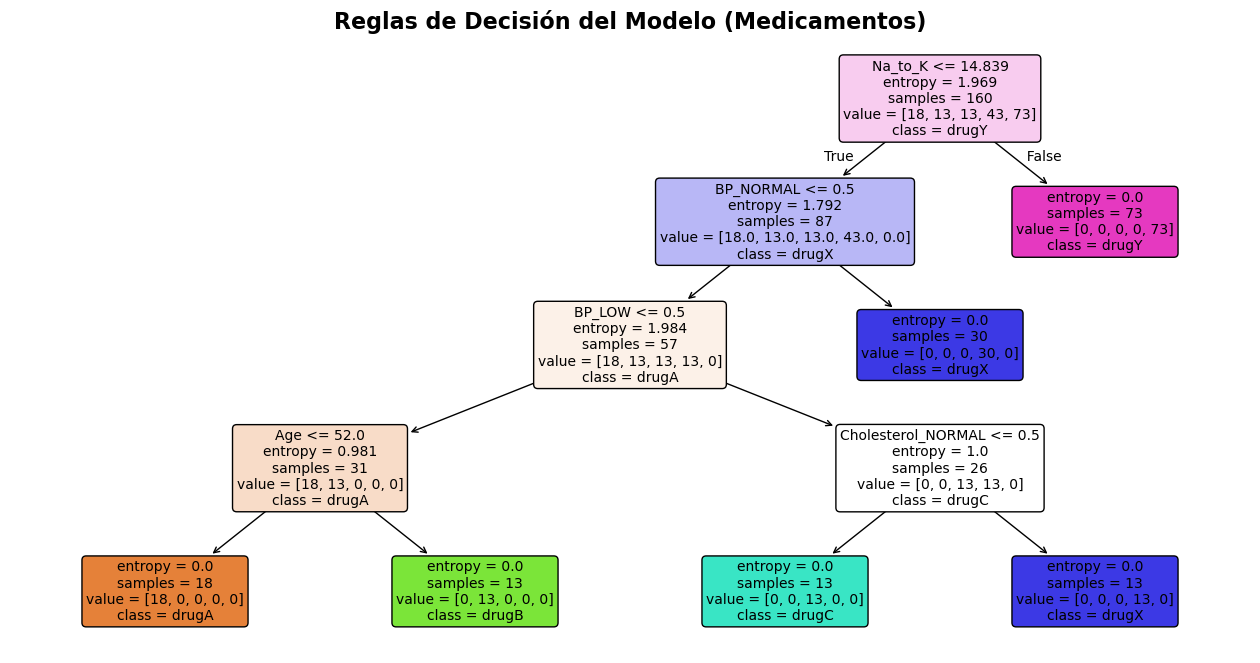

🔍 INTERPRETACIÓN DE LA GRÁFICA:
1. La primera regla que descubrió el modelo es: Si el nivel de Na_to_K es menor a 14.829, toma un camino, si no, receta DrugY.
2. El color de la caja indica la clase dominante. Mientras más intenso sea el color, más 'Puro' es el nodo.


In [8]:
# Generamos la visualización gráfica del árbol
plt.figure(figsize=(16,8))

# plot_tree dibuja las cajas y flechas con reglas lógicas
plot_tree(arbol_entropia,
         feature_names=X.columns,
        class_names=arbol_entropia.classes_,
        filled=True,
        rounded=True,
        fontsize=10)

plt.title("Reglas de Decisión del Modelo (Medicamentos)", fontsize=16, fontweight='bold')
plt.show()

print("🔍 INTERPRETACIÓN DE LA GRÁFICA:")
print("1. La primera regla que descubrió el modelo es: Si el nivel de Na_to_K es menor a 14.829, toma un camino, si no, receta DrugY.")
print("2. El color de la caja indica la clase dominante. Mientras más intenso sea el color, más 'Puro' es el nodo.")

## 🚀 Nivel Pro: Controlando el Crecimiento (Pruning / Poda)

Si dejamos que un árbol crezca sin restricciones, seguirá haciendo preguntas hasta que tenga una caja por cada paciente. Esto genera un modelo inmenso, incomprensible y propenso al **Overfitting** (Sobreajuste).

Para optimizar un modelo en producción, debemos "podar" el árbol limitando su **Profundidad Máxima (`max_depth`)** y la cantidad mínima de registros para dividirse. A continuación, usamos `GridSearchCV` para encontrar la arquitectura perfecta sin perder precisión.

In [10]:
from sklearn.model_selection import GridSearchCV

# Definimos una cuadrícula de hiperparámetros para probar miles de arquitecturas de árboles
parametros_arbol = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],           # Limintamos cuántos niveles puede bajar el árbol
    'min_samples_split': [2, 5, 10],           # Cuántos pacientes debe haber en un nodo para poder dividirse 
    'min_samples_leaf': [1, 2, 5]              # Cuántos pacientes mínimo deben quedar en una hoja final
}

print("Iniciando búsqueda de la arquitectura óptima del Árbol de Decisión...")
# cv= 5 indica Validación Cruzada de 5 pliegues 
grid_arbol = GridSearchCV(DecisionTreeClassifier(random_state=42), parametros_arbol, cv=5, scoring='accuracy', n_jobs=-1)
grid_arbol.fit(X_train, y_train)

# Extrayendo el modelo maestro
arbol_pro = grid_arbol.best_estimator_
y_pred_pro = arbol_pro.predict(X_test)

print("\n===🏆 RESULTADOS DEL MODELO OPTIMIZADO (PRO) ===")
print(f"Mejores Hiperparámetros encontrados: {grid_arbol.best_params_}")
print(f"Precisión Final en datos nuevos: {accuracy_score(y_test, y_pred_pro):.4f}")

# Mostramos el reporte completo para verificar que no hay clases ignoraadas 
print("\nReporte de Clasificación del Modelo Podado:")
print(classification_report(y_test, y_pred_pro))

Iniciando búsqueda de la arquitectura óptima del Árbol de Decisión...

===🏆 RESULTADOS DEL MODELO OPTIMIZADO (PRO) ===
Mejores Hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Precisión Final en datos nuevos: 0.9750

Reporte de Clasificación del Modelo Podado:
              precision    recall  f1-score   support

       drugA       0.83      1.00      0.91         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



## 📚 Glosario de Árboles de Decisión

* **Algoritmo de Hunt:** El método histórico "padre" de los árboles, basado en dividir recursivamente el conjunto de datos en subconjuntos más pequeños y homogéneos.
* **CART (Classification and Regression Trees):** Técnica moderna implementada en Python que construye árboles mediante divisiones estrictamente binarias (preguntas de Sí/No).
* **Codificación de variables cualitativas:** Proceso (`pd.get_dummies`) de transformar texto (como "HIGH", "LOW") en 1s y 0s para que la matemática del modelo funcione.
* **Criterio de Gini:** Métrica que evalúa la "impureza" de un nodo. Busca aislar la clase más grande en su propio nodo rápidamente.
* **Entropía:** Medida de la incertidumbre o desorden. Un nodo con 50/50 de pacientes tiene alta entropía; un nodo con 100% de la misma clase tiene entropía 0.
* **Graphviz / pydotplus:** Bibliotecas externas clásicas utilizadas para exportar visualizaciones de árboles a formatos como PNG o PDF. 
* **Matriz de Confusión:** Tabla que compara lo que el árbol predijo versus la realidad médica.
* **Nodos puros (Pure Nodes):** Hojas finales del árbol donde absolutamente todas las instancias pertenecen a una sola clase predictiva.
* **Reporte de clasificación:** Resumen numérico que incluye Precisión, Recall y F1-Score, desglosado para cada una de las clases (en este caso, para cada droga específica).

# 🎉 Conclusión del Módulo 23: Reglas Explicables

¡Felicidades por dominar la técnica de análisis supervisado más transparente del Machine Learning!

A diferencia de otros algoritmos, los Árboles de Decisión tienen una ventaja corporativa masiva: **la explicabilidad**. Si un doctor o un gerente nos pregunta por qué el modelo recomendó la "Droga Y", podemos imprimir el diagrama de flujo y mostrarle exactamente la ruta lógica (Ej. "Porque su sodio/potasio era mayor a 14.8").

### 🧠 ¿Qué nos llevamos de este módulo?
1. **El poder del Preprocesamiento:** Entendimos que un árbol de decisión necesita la codificación previa de variables cualitativas para poder plantear sus divisiones matemáticas.
2. **Matemática tras las decisiones:** Comprobamos que el modelo no lanza preguntas al azar, sino que optimiza basándose en la reducción de **Entropía** y la ganancia de **Gini**.
3. **Peligros del Crecimiento Infinito:** Descubrimos que la optimización (Pruning/Poda) de hiperparámetros como `max_depth` es vital para evitar el Overfitting.